# =============================================================================
# BASELINE DENSENET121 — TRAIN-VAL-TEST SPLIT EVALUATION
# =============================================================================
Evaluates the baseline DenseNet121 (frozen backbone → binary classification) on
**per-dataset** splits at configurable **train-val-test** ratios (60:20:20, 65:18:18, 70:15:15).

Dataset: **BHSig-Bengali**

**Prerequisites:**
1. Run `scripts/prepare_split_ratios.py` to generate split JSONs.

# =============================================================================
# STEP 1: SETUP, IMPORTS, AND REPRODUCIBILITY
# =============================================================================

In [1]:
import os
import sys
import json
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from PIL import Image

# Set repo root
current_dir = os.path.abspath(os.getcwd())
REPO_ROOT = os.path.abspath(os.path.join(current_dir, '..'))
if REPO_ROOT not in sys.path:
    sys.path.append(REPO_ROOT)

# Import Custom Modules
from models.feature_extractor import DenseNetFeatureExtractor
from utils.model_evaluation import compute_metrics, _plot_det_curve, _plot_far_frr, _plot_confusion_matrix, _plot_score_distribution, _plot_roc_curve
from dataloader.tDCBAM_trainloader import get_baseline_transforms

# Deterministic Seeding
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f" > [System] Seed set to: {seed}")

seed_everything(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" > [System] Device: {DEVICE}")
print(f" > [System] CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f" > [System] CUDA Device Name: {torch.cuda.get_device_name()}")


/home/lawrence/workspace/thesis/thesis/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


 > [System] Seed set to: 42
 > [System] Device: cuda
 > [System] CUDA Available: True
 > [System] CUDA Device Name: NVIDIA GeForce RTX 5080


# =============================================================================
# STEP 2: CONFIGURATION
# =============================================================================

In [2]:
# ────────────────────────────────────────────────────────────────────
# STEP 2: Configuration and Hyperparameters
# ────────────────────────────────────────────────────────────────────

# Notebook identifier
NOTEBOOK_NAME = 'baseline_bengali'
DATASET = 'bhsig_bengali'
DATASET_NAME = 'BHSig-Bengali'

# Paths
SPLIT_DIR = '../data/ratio_splits'
CHECKPOINT_DIR = '../checkpoints/baseline_splits'
EVAL_DIR = f'../model_evals/{NOTEBOOK_NAME}'

# Data splits - now using train:val:test ratios
SPLIT_RATIOS = ['65_18_18', '70_15_15', '60_20_20']

# Training Configuration
EPOCHS = 100
BATCH_SIZE = 30
LR = 1e-3
MOMENTUM = 0.99

# Data Configuration  
INPUT_SHAPE = (224, 224)
IMG_SIZE = 224
PREPROCESS = True
AUGMENT = True

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(EVAL_DIR, exist_ok=True)

print(" > Configuration loaded:")
print(f"   Dataset       : {DATASET_NAME}")
print(f"   Split Ratios  : {SPLIT_RATIOS}")
print(f"   Epochs        : {EPOCHS}")
print(f"   Batch Size    : {BATCH_SIZE}")
print(f"   Learning Rate : {LR}")
print(f"   Image Size    : {IMG_SIZE}x{IMG_SIZE}")
print(f"   Checkpoint Dir: {CHECKPOINT_DIR}")
print(f"   Eval Dir      : {EVAL_DIR}")


 > Configuration loaded:
   Dataset       : BHSig-Bengali
   Split Ratios  : ['65_18_18', '70_15_15', '60_20_20']
   Epochs        : 100
   Batch Size    : 30
   Learning Rate : 0.001
   Image Size    : 224x224
   Checkpoint Dir: ../checkpoints/baseline_splits
   Eval Dir      : ../model_evals/baseline_bengali


# =============================================================================
# STEP 3: GENERATE SPLITS (if not already generated)
# =============================================================================

# =============================================================================
# STEP 4: DATASET CLASS AND TRANSFORMS
# =============================================================================

In [3]:
class SplitDataset(Dataset):
    """
    Binary classification dataset (Genuine=0, Forged=1) from split JSON.
    Works with CEDAR, BHSig-Bengali, and BHSig-Hindi split files.
    """
    def __init__(self, user_dict, transform=None):
        self.samples = []
        self.transform = transform
        
        for uid, data in user_dict.items():
            # Handle both key styles: 'genuine'/'forged' and 'gen'/'forg'
            gen_key = next((k for k in data.keys() if k.lower() in ['genuine', 'gen']), None)
            forg_key = next((k for k in data.keys() if k.lower() in ['forged', 'forgeries', 'forg']), None)
            
            if gen_key:
                for path in data[gen_key]:
                    self.samples.append((path, 0))  # 0 = Genuine
            if forg_key:
                for path in data[forg_key]:
                    self.samples.append((path, 1))  # 1 = Forged
        
        num_gen = sum(1 for _, l in self.samples if l == 0)
        num_forg = sum(1 for _, l in self.samples if l == 1)
        print(f"   Dataset: {len(self.samples)} samples ({num_gen} genuine + {num_forg} forged) from {len(user_dict)} users")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            img = Image.open(img_path).convert('RGB')
            if self.transform:
                img = self.transform(img)
        except Exception as e:
            img = torch.zeros(3, IMG_SIZE, IMG_SIZE)
        return img, label

# Transforms
train_transform, val_transform = get_baseline_transforms(
    input_shape=INPUT_SHAPE, preprocess=PREPROCESS, augment=AUGMENT
)

print(" > Dataset class and transforms defined")

 > Dataset class and transforms defined


# =============================================================================
# STEP 5: TRAINING UTILITIES
# =============================================================================

In [4]:
def initialize_baseline_model(device):
    """Initialize DenseNet121 baseline with ImageNet pretrained weights."""
    num_classes = 2
    model = DenseNetFeatureExtractor(
        backbone_name='densenet121', output_dim=num_classes,
        pretrained=True, baseline=True
    ).to(device)
    print(f"   Using ImageNet initialization")
    return model


def train_one_epoch(model, loader, optimizer, criterion, device):
    """Train for one epoch, returns avg loss and accuracy."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    
    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    return total_loss / len(loader), correct / total


def evaluate_model(model, loader, device, output_dir=None, silent=False):
    """Evaluate model and compute metrics including EER."""
    model.eval()
    all_labels, all_scores = [], []
    
    iter_bar = tqdm(loader, desc="Evaluating", leave=False) if not silent else loader
    
    with torch.no_grad():
        for images, labels in iter_bar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            all_scores.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    metrics = compute_metrics(all_labels, all_scores)
    
    if output_dir and not silent:
        # Full Reporting
        print(f"\n{'='*10} FINAL TEST RESULTS {'='*10}")
        print(f"EER            : {metrics['eer']:.2%}")
        print(f"AUC            : {metrics['auc']:.4f}")
        print(f"Best Threshold : {metrics.get('threshold', 0):.4f}")
        print(f"Accuracy       : {metrics['accuracy']:.2%}")
        print(f"Precision      : {metrics.get('precision', 0):.2%}")
        print(f"Recall         : {metrics.get('recall', 0):.2%}")
        print(f"F1-Score       : {metrics.get('f1', 0):.2%}")
        print("="*40)
        
        _plot_roc_curve(metrics, output_dir)
        _plot_score_distribution(metrics, output_dir)
        _plot_confusion_matrix(metrics, output_dir)
        _plot_det_curve(metrics, output_dir)
        _plot_far_frr(metrics, output_dir)
    
    return metrics


def train_full_pipeline(model, train_loader, val_loader, device, 
                        epochs, lr, checkpoint_path):
    """
    Train-Val-Test strategy: Use train for optimization, val for model selection.
    Returns best validation metrics dict.
    """
    criterion = nn.CrossEntropyLoss()
    best_eer, best_acc, best_metrics = 1.0, 0.0, {}
    
    # All parameters trainable
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4, betas=(MOMENTUM, MOMENTUM))
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics = evaluate_model(model, val_loader, device, silent=True)
        val_eer, val_acc = val_metrics['eer'], val_metrics['accuracy']
        
        print(f"   Epoch {epoch+1:02d}/{epochs} | Loss: {train_loss:.4f} | "
              f"Acc: {train_acc:.2%} | Val EER: {val_eer:.2%} | Val Acc: {val_acc:.2%}")
        scheduler.step(val_eer)
        
        if val_eer < best_eer or (val_eer == best_eer and val_acc > best_acc):
            best_eer, best_acc, best_metrics = val_eer, val_acc, val_metrics
            torch.save({'model_state_dict': model.state_dict(), 'metrics': best_metrics}, checkpoint_path)
            print(f"   >>> Saved! (EER: {val_eer:.2%})")
    
    return best_metrics


print(" > Training utilities defined")


 > Training utilities defined


# =============================================================================
# STEP 6: RUN ALL SPLIT RATIOS
# =============================================================================

In [5]:
all_results = {}

for ratio in SPLIT_RATIOS:
    split_file = os.path.join(SPLIT_DIR, f"{DATASET}_split_{ratio}.json")
    train_pct, val_pct, test_pct = ratio.split('_')
    split_eval_dir = os.path.join(EVAL_DIR, f"{NOTEBOOK_NAME}_{train_pct}-{val_pct}-{test_pct}")
    os.makedirs(split_eval_dir, exist_ok=True)
    
    print(f"\n{'='*60}")
    print(f" {DATASET_NAME} -- {train_pct}:{val_pct}:{test_pct} Split")
    print(f"{'='*60}")
    
    if not os.path.exists(split_file):
        print(f"   SKIPPED: Split file not found: {split_file}")
        continue
    
    # Load split - now with train/val/test
    with open(split_file, 'r') as f:
        split_data = json.load(f)
    
    train_dict = split_data['train']
    val_dict = split_data['val']
    test_dict = split_data['test']
    
    print(f"   Train users: {len(train_dict)} | Val users: {len(val_dict)} | Test users: {len(test_dict)}")
    
    # Create datasets
    print("   Creating train dataset...")
    train_dataset = SplitDataset(train_dict, transform=train_transform)
    print("   Creating val dataset...")
    val_dataset = SplitDataset(val_dict, transform=val_transform)
    print("   Creating test dataset...")
    test_dataset = SplitDataset(test_dict, transform=val_transform)
    
    if len(train_dataset) == 0 or len(val_dataset) == 0 or len(test_dataset) == 0:
        print(f"   SKIPPED: Empty dataset")
        continue
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                              num_workers=4, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=4, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=4, pin_memory=True)
    
    # Initialize model
    seed_everything(42)
    model = initialize_baseline_model(DEVICE)
    
    # Train using train set, validate on val set for model selection
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"best_{DATASET}_{ratio}.pth")
    best_val_metrics = train_full_pipeline(
        model, train_loader, val_loader, DEVICE,
        epochs=EPOCHS, lr=LR,
        checkpoint_path=ckpt_path
    )
    
    # Load best checkpoint and evaluate on test set (NEVER seen during training)
    if os.path.exists(ckpt_path):
        checkpoint = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        state = checkpoint.get('model_state_dict', checkpoint)
        model.load_state_dict(state)
    
    final_test_metrics = evaluate_model(model, test_loader, DEVICE, output_dir=split_eval_dir, silent=False)
    
    # Record results
    result_key = f"{DATASET_NAME} ({train_pct}:{val_pct}:{test_pct})"
    all_results[result_key] = {
        'dataset': DATASET_NAME,
        'split': f"{train_pct}:{val_pct}:{test_pct}",
        'train_users': len(train_dict),
        'val_users': len(val_dict),
        'test_users': len(test_dict),
        'eer': float(final_test_metrics['eer']),
        'accuracy': float(final_test_metrics['accuracy']),
        'auc': float(final_test_metrics['auc']),
        'precision': float(final_test_metrics['precision']),
        'recall': float(final_test_metrics['recall']),
        'f1': float(final_test_metrics['f1']),
    }
    
    print(f"\n   TEST SET RESULT: EER={final_test_metrics['eer']:.2%} | Acc={final_test_metrics['accuracy']:.2%} | "
          f"AUC={final_test_metrics['auc']:.4f} | F1={final_test_metrics['f1']:.4f}")

print(f"\n{'='*60}")
print("ALL EXPERIMENTS COMPLETE")
print(f"{'='*60}")



 BHSig-Bengali -- 65:18:18 Split
   Train users: 65 | Val users: 18 | Test users: 17
   Creating train dataset...
   Dataset: 3510 samples (1560 genuine + 1950 forged) from 65 users
   Creating val dataset...
   Dataset: 972 samples (432 genuine + 540 forged) from 18 users
   Creating test dataset...
   Dataset: 918 samples (408 genuine + 510 forged) from 17 users
 > [System] Seed set to: 42
   Using ImageNet initialization


Training:   0%|          | 0/117 [00:00<?, ?it/s]

   Epoch 01/100 | Loss: 0.5823 | Acc: 72.45% | Val EER: 19.68% | Val Acc: 80.45%
   >>> Saved! (EER: 19.68%)


Training:   0%|          | 0/117 [00:00<?, ?it/s]

   Epoch 02/100 | Loss: 0.5143 | Acc: 76.70% | Val EER: 16.90% | Val Acc: 83.23%
   >>> Saved! (EER: 16.90%)


...

   Epoch 99/100 | Loss: 0.3851 | Acc: 82.96% | Val EER: 21.67% | Val Acc: 78.43%


Training:   0%|          | 0/108 [00:00<?, ?it/s]

   Epoch 100/100 | Loss: 0.3968 | Acc: 81.98% | Val EER: 21.88% | Val Acc: 78.15%


Evaluating:   0%|          | 0/36 [00:00<?, ?it/s]


========== FINAL TEST RESULTS ==========
EER            : 18.54%
AUC            : 0.8921
Best Threshold : 0.4087
Accuracy       : 81.57%
Precision      : 84.63%
Recall         : 81.67%
F1-Score       : 83.12%
 > Saved ROC Plot to: ../model_evals/baseline_bengali/baseline_bengali_60-20-20/roc_curve.png
 > Saved Distribution Plot to: ../model_evals/baseline_bengali/baseline_bengali_60-20-20/score_distribution.png
 > Saved Confusion Matrix to: ../model_evals/baseline_bengali/baseline_bengali_60-20-20/confusion_matrix.png
 > Saved DET Curve to: ../model_evals/baseline_bengali/baseline_bengali_60-20-20/det_curve.png
 > Saved FAR/FRR Plot to: ../model_evals/baseline_bengali/baseline_bengali_60-20-20/far_frr.png

   TEST SET RESULT: EER=18.54% | Acc=81.57% | AUC=0.8921 | F1=0.8312

ALL EXPERIMENTS COMPLETE


# =============================================================================
# STEP 7: SUMMARY TABLE
# =============================================================================

In [6]:
# Print summary table
print(f"\n{'='*80}")
print(f"{'BASELINE DENSENET121 — ' + DATASET_NAME + ' SPLIT EVALUATION':^80}")
print(f"{'='*80}")
print(f"{'Split':<10} {'Train':<8} {'Val':<8} {'Test':<8} {'EER':<10} {'Accuracy':<10} {'AUC':<10} {'F1':<10}")
print(f"{'-'*80}")

for key, res in all_results.items():
    print(f"{res['split']:<10} {res['train_users']:<8} {res['val_users']:<8} {res['test_users']:<8} "
          f"{res['eer']:.4f}    {res['accuracy']:.4f}    {res['auc']:.4f}    {res['f1']:.4f}")

print(f"{'='*70}")

# Save results
results_path = os.path.join(CHECKPOINT_DIR, f'baseline_{DATASET}_results.json')
with open(results_path, 'w') as f:
    json.dump(all_results, f, indent=2)
print(f"\n > Results saved to: {results_path}")


             BASELINE DENSENET121 — BHSig-Bengali SPLIT EVALUATION              
Split      Train    Val      Test     EER        Accuracy   AUC        F1        
--------------------------------------------------------------------------------
65:18:18   65       18       17       0.2059    0.7963    0.8948    0.8132
70:15:15   70       15       15       0.1972    0.8037    0.8964    0.8199
60:20:20   60       20       20       0.1854    0.8157    0.8921    0.8312

 > Results saved to: ../checkpoints/baseline_splits/baseline_bhsig_bengali_results.json


# =============================================================================
# STEP 8: VISUALIZATION
# =============================================================================

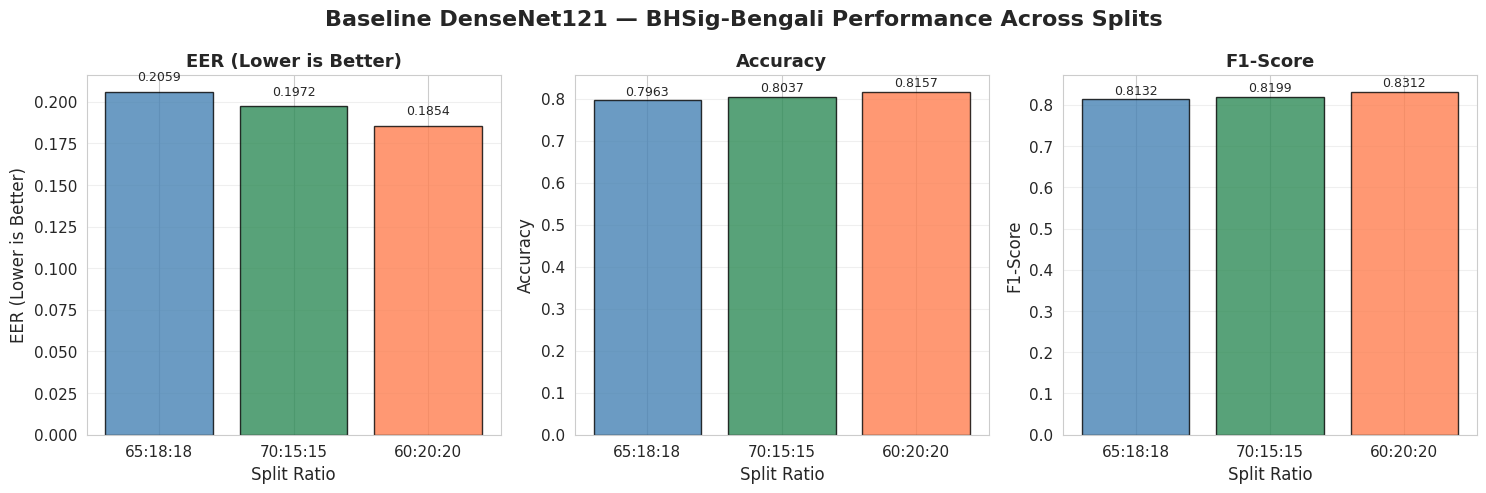

 > Plot saved to: ../checkpoints/baseline_splits/baseline_bhsig_bengali_comparison.png


In [7]:
# Bar chart: Metrics by split ratio
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Baseline DenseNet121 — {DATASET_NAME} Performance Across Splits', fontsize=16, fontweight='bold')

metrics_to_plot = ['eer', 'accuracy', 'f1']
titles = ['EER (Lower is Better)', 'Accuracy', 'F1-Score']
colors = ['steelblue', 'seagreen', 'coral']

for ax_idx, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    ax = axes[ax_idx]
    split_labels = []
    values = []
    
    for ratio in SPLIT_RATIOS:
        split_str = ratio.replace('_', ':')
        split_labels.append(split_str)
        key = f"{DATASET_NAME} ({split_str})"
        values.append(all_results.get(key, {}).get(metric, 0))
    
    bars = ax.bar(split_labels, values, color=colors, alpha=0.8, edgecolor='black')
    ax.set_xlabel('Split Ratio', fontsize=12)
    ax.set_ylabel(title, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plot_path = os.path.join(CHECKPOINT_DIR, f'baseline_{DATASET}_comparison.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f" > Plot saved to: {plot_path}")